# Sampling and Monte Carlo Methods

Many problems in physics and machine learning require evaluating an integral, an expectation value, or a high-dimensional function over a large or continuous domain , for example the partition function of a statistical system, a Bayesian posterior, or an expectation value $\langle \mathcal{O} \rangle$ over some probability distribution. If evaluating the function everywhere (grid-based methods) is computationally too expensive we cannot afford to evaluate it exhaustively.

Sampling solves this by instead drawing a finite set of random points from the relevant domain and using them to estimate the quantity of interest, rather than computing it exactly. This is the core idea behind **Monte Carlo methods**: replace exact but intractable computation with a statistical estimate that converges to the true answer as the number of samples $N$ increases, typically with error $\sim 1/\sqrt{N}$, independent of the dimensionality of the problem , which is precisely why Monte Carlo methods scale so much better than grid-based methods in high dimensions.

## Example: Estimating $\pi$ by sampling

A classic illustration of Monte Carlo integration is estimating $\pi$ using only random sampling and the equation of a circle.
Consider a circle of radius $r=1$ inscribed in a square of side length $2$ (spanning $[-1,1]\times[-1,1]$). The area of the circle is $\pi r^2 = \pi$, and the area of the square is $4$. If we draw points $(x,y)$ uniformly inside the square, the probability that a point falls inside the circle equals the ratio of areas:
$$
    P(\text{inside circle}) = \frac{\pi}{4}
$$
A point lies inside the circle if it satisfies the circle equation $x^2 + y^2 \leq 1$. So the algorithm is:

1. Draw $N$ points $(x_i, y_i)$ uniformly from $[-1,1]\times[-1,1]$.
2. Count how many satisfy $x_i^2 + y_i^2 \leq 1$ , call this $N_{\text{inside}}$.
3. Estimate $\pi \approx 4 \cdot \dfrac{N_{\text{inside}}}{N}$.

No knowledge of $\pi$ is needed anywhere in this procedure , it emerges purely from the geometry and the law of large numbers. The estimate converges to the true value of $\pi$ as $N \to \infty$, with a statistical (Monte Carlo) error that shrinks as $1/\sqrt{N}$.


In [7]:
import numpy as np

N = 10**7
x = np.random.uniform(-1, 1, N)
y = np.random.uniform(-1, 1, N)

inside = (x**2 + y**2) <= 1   # circle equation      
pi_estimate = 4 * np.sum(inside) / N
error = np.abs(np.pi - pi_estimate)

print(rf"Estimated pi: {pi_estimate}, with error {error} (close to expected error of {1/np.sqrt(N)}).")

Estimated pi: 3.1409884, with error 0.0006042535897932133 (close to expected error of 0.00031622776601683794).



## Intelligent sampling: exploiting symmetry

The estimate above can be made more compute-efficient by exploiting the symmetry of the problem, without changing the underlying statistics.
The circle-in-square setup has 4-fold symmetry: the quarter circle in $[0,1]\times[0,1]$ contains exactly the same information as the full circle, since the other three quadrants are just reflections of it. We can therefore sample only in the first quadrant:
$$
P(\text{inside quarter circle} \mid x,y \in [0,1]) = \frac{\pi/4}{1} = \frac{\pi}{4}
$$
This gives the same estimator and the same statistical precision for a given $N$, but each sample now requires generating and evaluating half as many random numbers per dimension (no negative half of the range to cover), and the acceptance ratio $N_{\text{inside}}/N$ stays at $\pi/4 \approx 0.785$, unchanged , so no efficiency is lost, only redundant computation is removed. In general, exploiting known symmetries (reflection, rotation, periodicity) of a problem is one of the simplest and most effective ways to reduce the compute cost of a Monte Carlo estimate without sacrificing accuracy.

# Sampling from a Given Probability Distribution

Sampling uniformly, as above, is straightforward , most programming languages provide a built-in uniform random number generator. But often we need samples $x_i$ distributed according to some specific, non-uniform probability density function (PDF) $f(x)$, for example a Gaussian, an exponential, or a combination of the two , and there may be no built-in sampler for that particular distribution (e.g. the sum of two Gaussians, or a Gaussian plus an exponential background, which are common in physics fits). Two general-purpose methods solve this problem: **inverse transform sampling** and **rejection sampling**.


## Inverse Transform Sampling (Inverse CDF method)

Every PDF $f(x)$ has an associated cumulative distribution function (CDF):
$$
    F(x) = \int_{-\infty}^{x} f(x') \, dx'
$$
which is monotonically increasing and maps $x$ to a value in $[0,1]$. The key idea: if $U$ is a uniform random variable on $[0,1]$, then
$$
    X = F^{-1}(U)
$$
is distributed according to $f(x)$. Intuitively, the CDF "stretches" or "compresses" the uniform distribution so that more probable regions of $x$ (where $f(x)$ is large, i.e. $F(x)$ rises steeply) receive proportionally more samples.

**Algorithm:**
1. Compute (or numerically approximate) the CDF $F(x)$ of the target distribution.
2. Invert it to get $F^{-1}(u)$.
3. Draw $u \sim \text{Uniform}(0,1)$ and compute $x = F^{-1}(u)$.

### Example: exponential distribution
Consider the PDF $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$. We have
$$
F(x) = 1 - e^{-\lambda x} \quad\Rightarrow\quad F^{-1}(u) = -\frac{1}{\lambda}\ln(1-u)
$$

**The problem:** for many distributions relevant in practice , e.g. the sum of two Gaussians (a common signal+background model), or a Gaussian convolved with an exponential , the CDF has no closed-form analytic inverse. $F(x)$ can still be computed numerically (e.g. by integrating $f(x)$ on a grid), but inverting it requires numerical root-finding or interpolation for every sample, which works but adds complexity and computational cost, especially in higher dimensions.


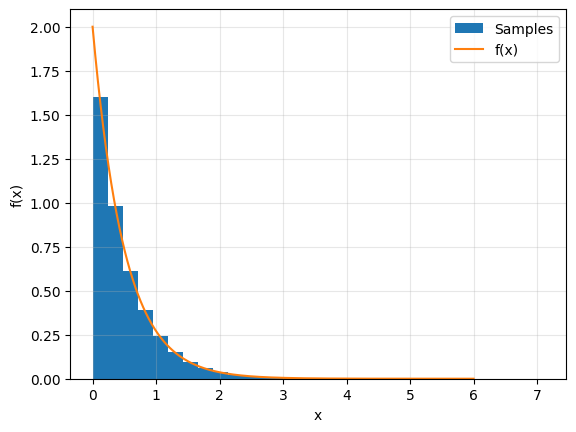

In [17]:
import matplotlib.pyplot as plt

# Get samples from f
lam = 2.0
u = np.random.uniform(0, 1, size=10**5)
samples_of_f = -np.log(1 - u) / lam   # inverse (analytical) CDF of the exponential distribution

# Display result
x = np.linspace(0,6, 1000)
f = lam*np.exp(-lam*x)
plt.hist(samples_of_f, bins=30, density=True, label="Samples") # density parameter normalizes counts
plt.plot(x, f, label="f(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylabel("f(x)")
plt.xlabel("x")
plt.show()


## Rejection Sampling

When the CDF cannot be inverted easily, rejection sampling offers a simple, general-purpose alternative that works for any PDF $f(x)$ that can be evaluated pointwise , no CDF or inversion required at all.

**Idea:** enclose $f(x)$ under a simpler "envelope" distribution $g(x)$ (often just a uniform distribution) scaled by a constant $M$ such that $M \cdot g(x) \geq f(x)$ everywhere on the domain of interest. Then:

1. Draw a candidate $x \sim g(x)$ (e.g. uniformly from the domain).
2. Draw $u \sim \text{Uniform}(0,1)$.
3. **Accept** $x$ if $u \leq \dfrac{f(x)}{M \cdot g(x)}$, otherwise **reject** and repeat.

Accepted samples are then distributed exactly according to $f(x)$.

### Example: sum of two Gaussians
Consider the PDF
$f(x) = 0.5\,\mathcal{N}(x;\mu_1,\sigma_1) + 0.5\,\mathcal{N}(x;\mu_2,\sigma_2)$, using a uniform envelope over $[a,b]$:

**Trade-off:** rejection sampling is easy to implement and needs no CDF at all, but its efficiency depends entirely on how tightly the envelope $M \cdot g(x)$ bounds $f(x)$ , a loose envelope leads to a high rejection rate and wasted computation, while a tight envelope (ideally matching the shape of $f(x)$, e.g. using a mixture of Gaussians as the envelope for a mixture-of-Gaussians target) makes the method far more efficient. This trade-off between simplicity (uniform envelope) and efficiency (tailored envelope) is exactly the kind of "intelligent sampling" trade-off already seen in the $\pi$-estimation example above, and becomes increasingly important in higher dimensions, motivating more advanced sampling schemes such as Markov Chain Monte Carlo (MCMC), which will be needed later for sampling the Ising model.

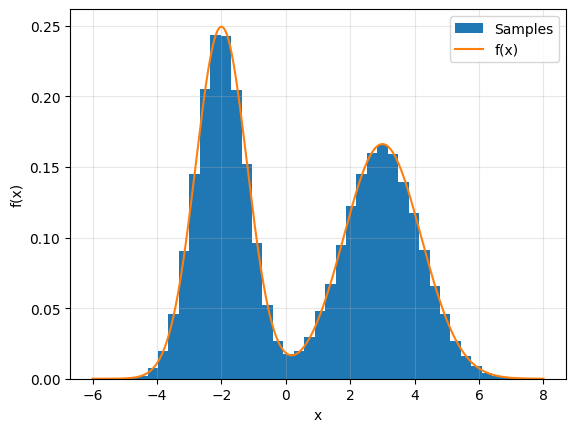

In [20]:
# Fefine PDF
def f(x):
    g1 = np.exp(-0.5*((x - (-2))/0.8)**2) / (0.8*np.sqrt(2*np.pi))
    g2 = np.exp(-0.5*((x - 3)/1.2)**2) / (1.2*np.sqrt(2*np.pi))
    return 0.5*g1 + 0.5*g2

a, b = -6, 8            # sampling domain
M = 0.3                 # upper bound on f(x) in [a, b] (chosen so that M >= max(f))

# Reject sampling
samples = []
while len(samples) < 10**5:
    x_candidate = np.random.uniform(a, b)
    u = np.random.uniform(0, 1)
    if u <= f(x_candidate) / M:
        samples.append(x_candidate)

# Display results
x = np.linspace(-6,8, 1000)
f = f(x)
plt.hist(samples, bins=40, density=True, label="Samples") # density parameter normalizes counts
plt.plot(x, f, label="f(x)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylabel("f(x)")
plt.xlabel("x")
plt.show()